# M3: cluster-based permutation testing

Replicates `ssveps/templateCode/permTestingcomparisons/*.m` -- cluster-based
permutation testing (Maris & Oostenveld style) between two groups' mean
grids, generalized into `scripts/permutation.py` instead of the template's
copy-pasted, hardcoded-subject-list scripts. Method and decisions are
documented in `docs/methods.md`; every function's signature is in
`docs/api_reference.md`.

Two decisions carried over deliberately from the template (confirmed, not
assumed): every permutation subsamples both groups down to `n1`/`n2`
subjects (default: both balanced to the smaller group's size) rather than
using the full, unequal group sizes -- this keeps the null distribution
comparable to the observed statistic instead of swamped by the larger group.
One fix vs. the template: `permutation_test_directional`'s negative-cluster
null now uses each permutation's most extreme (min) cluster weight, not
`max` -- the template's `max` over negative sums picked the *weakest*
negative cluster every time, which would have made the negative-cluster
correction too lenient.

In [ ]:
import sys
sys.path.append('../scripts')

import numpy as np

from analysis import load_runmap, load_baselines, load_metadata
import permutation as pm
import plotting as pl

runmap_df = load_runmap()
baselines_df = load_baselines()
metadata_df = load_metadata()

SESSION = 1
SEED = 0  # fixed for reproducibility -- the template's original MATLAB scripts didn't seed their RNG at all

## Level 1: cluster-size correction
Replicates `group_permTesting_01JULY25.m`. Two-tailed z-threshold, then the
observed clusters are kept only if their size exceeds the 95th percentile of
every permutation's own max cluster size -- protan vs. CTR shown here (the
smallest, most likely to show a real difference given fewer averaging runs).

n1=8, n2=8, size_thresh=21.0


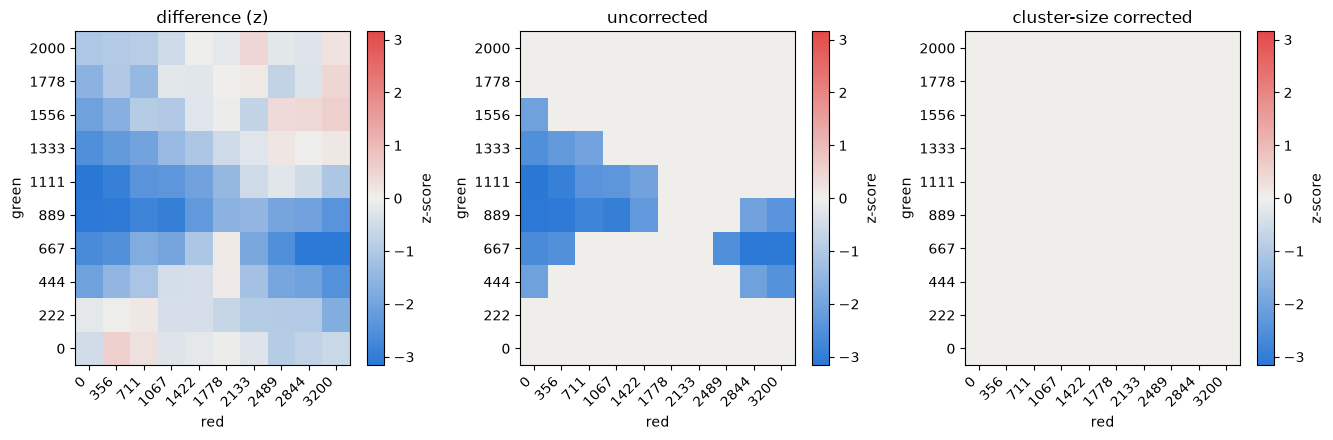

In [2]:
size_result = pm.permutation_test_size(
    runmap_df, baselines_df, metadata_df, SESSION,
    subgroup1='protan', group2='CTR', n_perm=1000, seed=SEED,
)
print(f"n1={size_result['n1']}, n2={size_result['n2']}, size_thresh={size_result['size_thresh']:.1f}")
pl.plot_permutation_test_size(size_result);

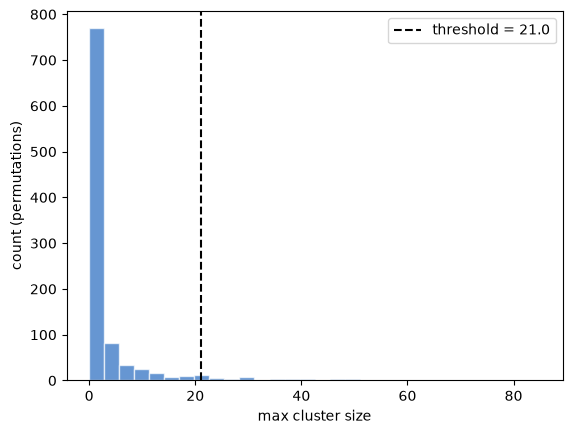

In [3]:
pl.plot_permutation_null_histogram(size_result['null_sizes'], size_result['size_thresh'], xlabel='max cluster size');

## Level 2: cluster-size + cluster-weight correction
Replicates `groupPermTesting_clustSize_custWeight.m`. Adds a second
correction criterion -- cluster weight (sum of |z| in the cluster) -- and a
per-cluster p-value (fraction of permutations whose own max cluster weight
exceeds that cluster's).

surviving clusters (uncorrected): [{'size': 17, 'weight': np.float64(43.02790027975719), 'pvalue': np.float64(0.057)}, {'size': 7, 'weight': np.float64(17.684910279861306), 'pvalue': np.float64(0.122)}]


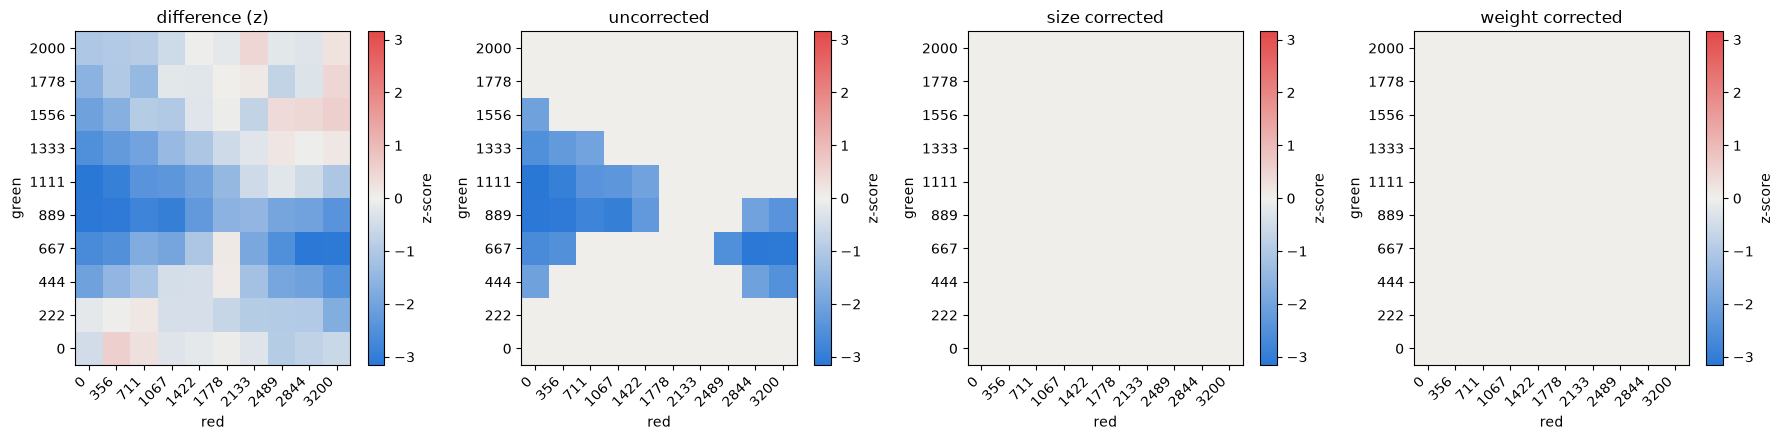

In [4]:
weighted_result = pm.permutation_test_weighted(
    runmap_df, baselines_df, metadata_df, SESSION,
    subgroup1='protan', group2='CTR', n_perm=1000, seed=SEED,
)
print('surviving clusters (uncorrected):', weighted_result['cluster_results'])
pl.plot_permutation_test_weighted(weighted_result);

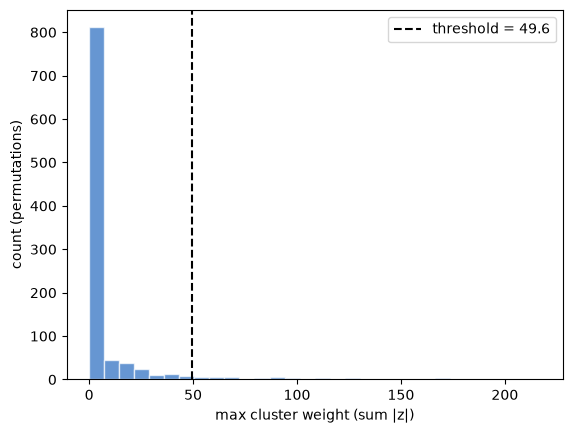

In [5]:
pl.plot_permutation_null_histogram(weighted_result['null_weights'], weighted_result['weight_thresh'], xlabel='max cluster weight (sum |z|)');

## Level 3: positive/negative cluster separation
Replicates `group_permTesting_positive_negative_clusters.m`, with the
negative-cluster min/max fix noted above. Separates elevated (positive) and
suppressed (negative) clusters, each with its own null distribution and
size/weight correction -- the three group comparisons decided on: PD,
protan, and deutan, each vs. HC (=CTR).

In [6]:
comparisons = [
    {'label': 'PD vs HC', 'kwargs': dict(group1='PD', group2='CTR')},
    {'label': 'protan vs HC', 'kwargs': dict(subgroup1='protan', group2='CTR')},
    {'label': 'deutan vs HC', 'kwargs': dict(subgroup1='deutan', group2='CTR')},
]

directional_results = {}
for comp in comparisons:
    result = pm.permutation_test_directional(
        runmap_df, baselines_df, metadata_df, SESSION, n_perm=1000, seed=SEED, **comp['kwargs'],
    )
    directional_results[comp['label']] = result
    print(f"{comp['label']} (n1={result['n1']}, n2={result['n2']}): {result['cluster_results']}")

PD vs HC (n1=6, n2=6): []


protan vs HC (n1=8, n2=8): [{'sign': 'neg', 'size': 17, 'weight': np.float64(-43.02790027975719), 'pvalue': np.float64(0.03)}, {'sign': 'neg', 'size': 7, 'weight': np.float64(-17.684910279861306), 'pvalue': np.float64(0.059)}]


deutan vs HC (n1=7, n2=7): [{'sign': 'neg', 'size': 45, 'weight': np.float64(-108.3980383084267), 'pvalue': np.float64(0.014)}]


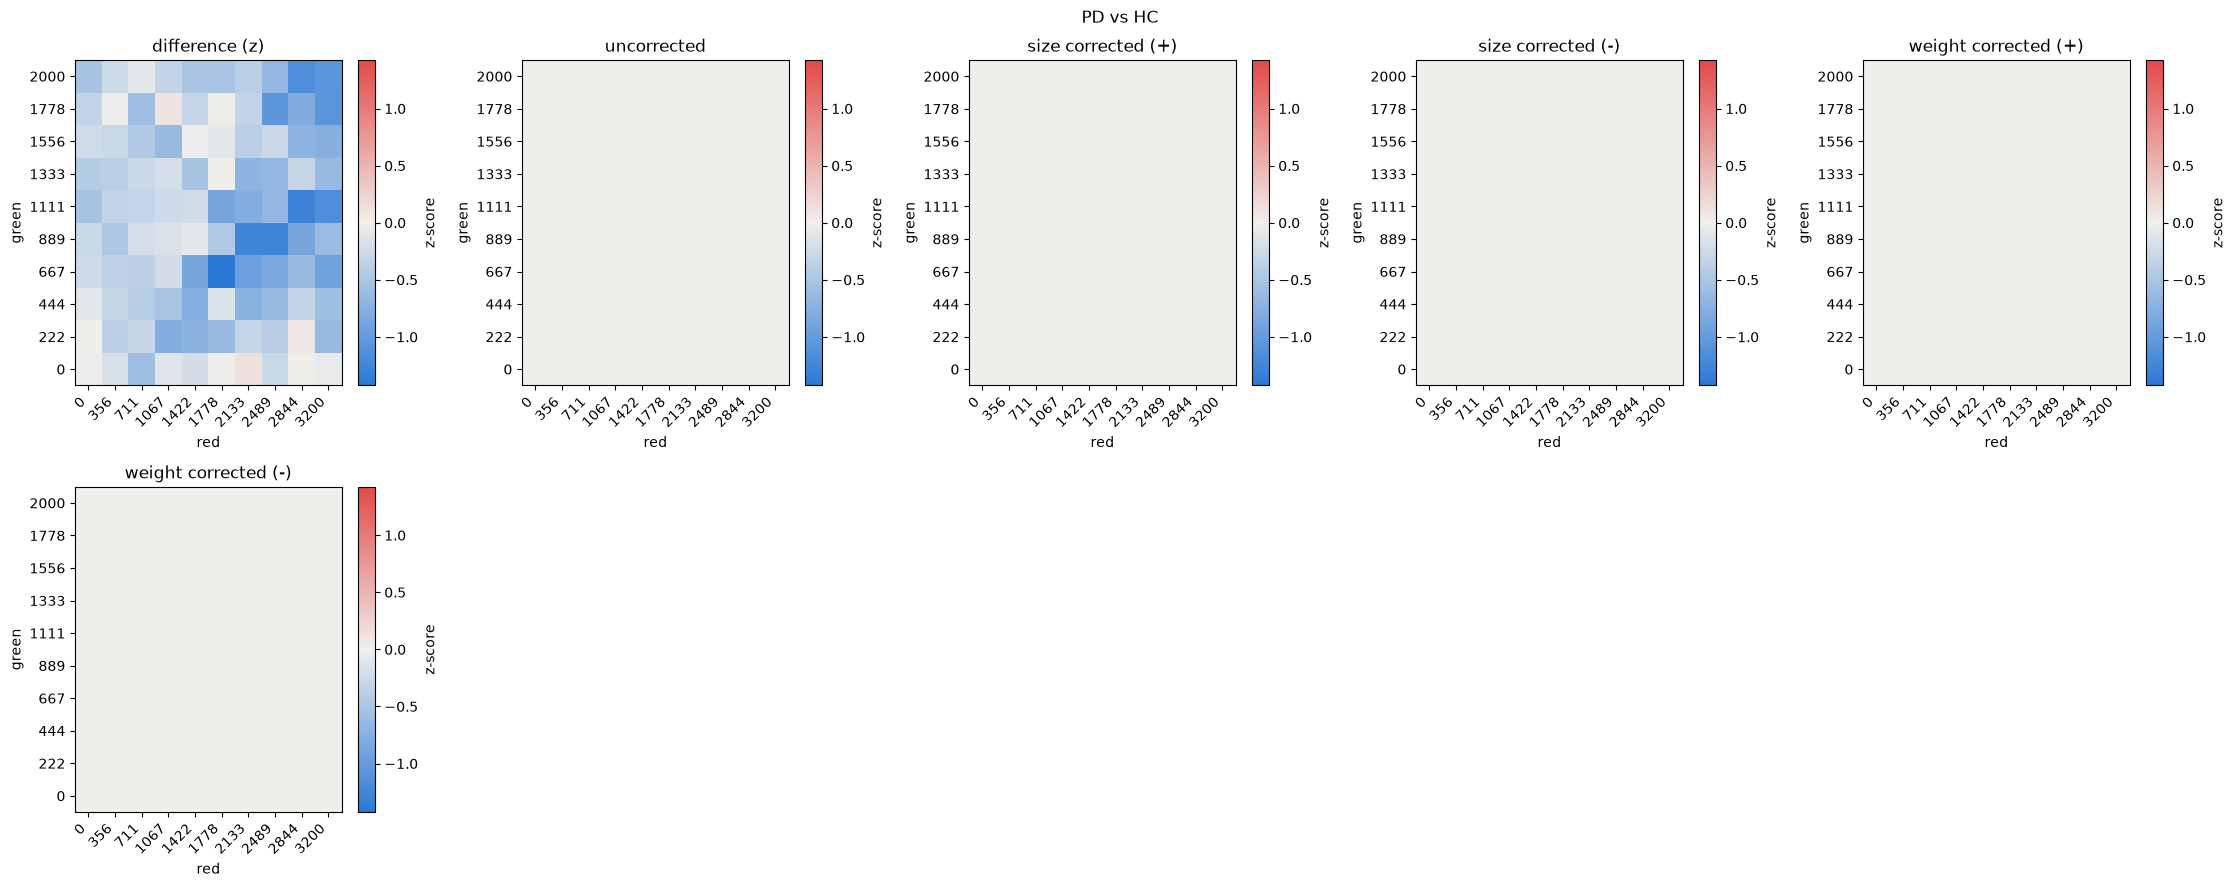

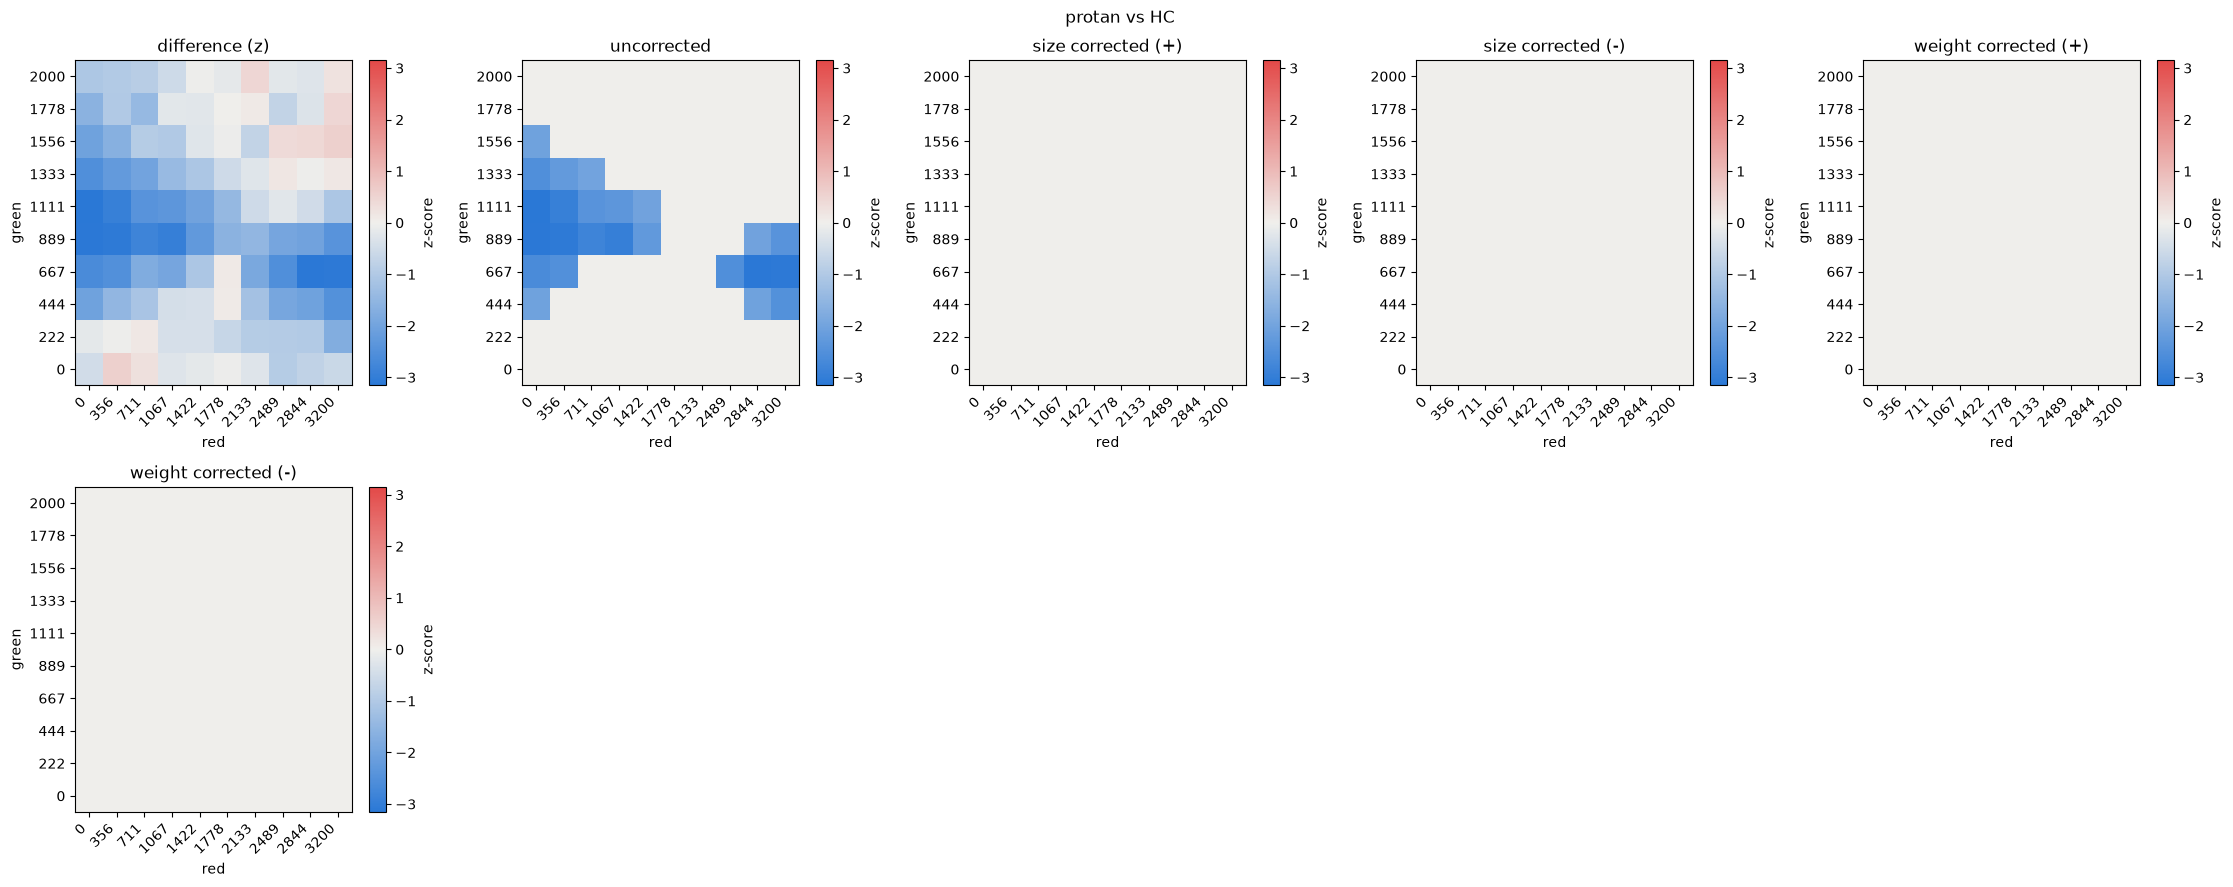

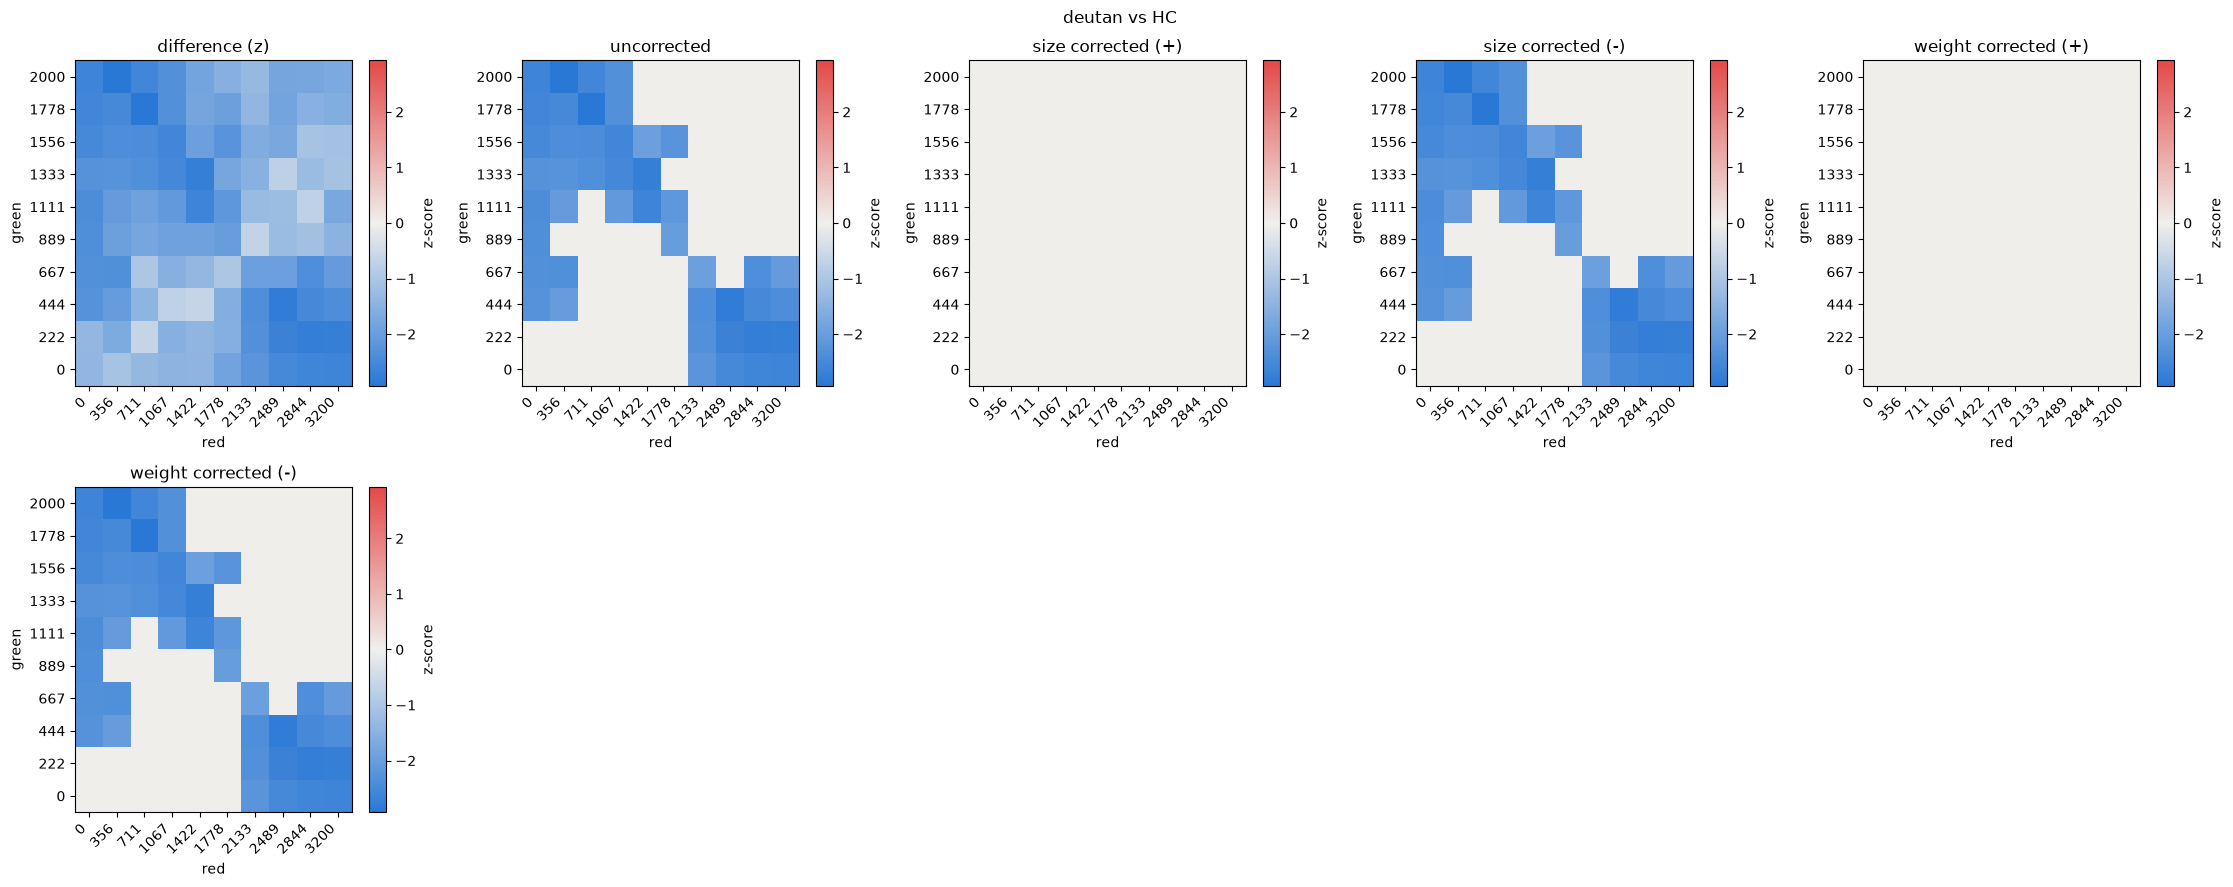

In [7]:
for label, result in directional_results.items():
    pl.plot_permutation_test_directional(result, title=label)

## Notes on the template's improvements
- **Subsampling (confirmed intentional)**: with very unequal group sizes
  (e.g. protan n=10 vs. CTR n=21), every permutation subsamples both groups
  to `n1=n2=min(group sizes)` by default -- this is now a parameter
  (`n1`/`n2`) rather than hardcoded magic numbers per comparison.
- **Negative-cluster statistic (fixed)**: see the top of this notebook and
  `permutation.py`'s module docstring.
- **Consolidation**: the template's 6 near-identical scripts (one per group
  pair, each hardcoding its own subject list) became 3 reusable functions
  parameterized by `group`/`subgroup`, reusing `analysis.subjects_in_group`/
  `mean_grid` -- any group/subgroup pair works without writing a new script.
- **Reproducibility (added)**: every function takes a `seed`, so results
  (and this notebook's output) are reproducible -- the original MATLAB
  scripts never seeded their RNG.
- **Per-cluster p-values for the directional case (added)**: the template
  computed per-cluster p-values only for the non-directional, size+weight
  script; `permutation_test_directional` extends the same logic to the
  positive/negative-separated case.